## Project Title: Traffic Accident Risk Prediction (TARP)

**Unit:** SIT782  
**Prepared by:** Burhanuddin Ujjainwala  
**Project Team:** Suba (225094537), Burhanuddin (224802775), Khalid (224696667)  
**Task:** Importing, exploration and Exploratory Data Analysis of Melbourne Weather Data


## Dataset source

Official dataset: **Bureau of Meteorology data** from the Bureau of Meteorology data portal.

Historical dataset: **Historical data** from the Weatherzone data portal.

For this notebook, we are using the **weather** dataset, which contains records such as minimum temperature, maximum temperature, rainfall, Direction of maximum wind, Speed of maximum wind gust, temperature and humidity of day at different time, and much more.


In [1]:

import pandas as pd
import numpy as np
import warnings
from pathlib import Path
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)


## Loading each file 

In [13]:
from pathlib import Path

LOCAL_BASE_DIR = Path(r"D:/Project/MOP-Code/Playground/BurhanT12026/Traffic_Accident_Prediction/data/raw")
FALLBACK_BASE_DIR = Path(".")
BASE_DIR = LOCAL_BASE_DIR if LOCAL_BASE_DIR.exists() else FALLBACK_BASE_DIR

print("Using data directory:", BASE_DIR.resolve())

weather_2015_2016 = pd.read_csv(BASE_DIR / "Weather_Observation_2015_2016 part 2.csv", delimiter=",", encoding="ISO-8859-1", header=5)

feb_25 = pd.read_csv(BASE_DIR / "Weather_Observation_February_2025.csv", delimiter=",", encoding="ISO-8859-1", header=4)
mar_25 = pd.read_csv(BASE_DIR / "Weather_Observation_March_2025.csv", delimiter=",", encoding="ISO-8859-1", header=4)
apr_25 = pd.read_csv(BASE_DIR / "Weather_Observation_April_2025.csv", delimiter=",", encoding="ISO-8859-1", header=4)
may_25 = pd.read_csv(BASE_DIR / "Weather_Observation_May_2025.csv", delimiter=",", encoding="ISO-8859-1", header=4)
jun_25 = pd.read_csv(BASE_DIR / "Weather_Observation_June_2025.csv", delimiter=",", encoding="ISO-8859-1", header=4)
jul_25 = pd.read_csv(BASE_DIR / "Weather_Observation_July_2025.csv", delimiter=",", encoding="ISO-8859-1", header=4)
aug_25 = pd.read_csv(BASE_DIR / "Weather_Observation_August_2025.csv", delimiter=",", encoding="ISO-8859-1", header=4)
sep_25 = pd.read_csv(BASE_DIR / "Weather_Observation_September_2025.csv", delimiter=",", encoding="ISO-8859-1", header=4)
oct_25 = pd.read_csv(BASE_DIR / "Weather_Observation_October_2025.csv", delimiter=",", encoding="ISO-8859-1", header=4)
nov_25 = pd.read_csv(BASE_DIR / "Weather_Observation_November_2025.csv", delimiter=",", encoding="ISO-8859-1", header=4)
dec_25 = pd.read_csv(BASE_DIR / "Weather_Observation_December_2025.csv", delimiter=",", encoding="ISO-8859-1", header=4)

jan_26 = pd.read_csv(BASE_DIR / "Weather_Observation_January_2026.csv", delimiter=",", encoding="ISO-8859-1", header=4)
feb_26 = pd.read_csv(BASE_DIR / "Weather_Observation_February_2026.csv", delimiter=",", encoding="ISO-8859-1", header=4)

print("Historical and monthly weather files loaded successfully.")

Using data directory: D:\Project\MOP-Code\Playground\BurhanT12026\Traffic_Accident_Prediction\data\raw
Historical and monthly weather files loaded successfully.


In [3]:
datasets = {
    "2015-2016": weather_2015_2016,
    "Feb 2025": feb_25,
    "Mar 2025": mar_25,
    "Apr 2025": apr_25,
    "May 2025": may_25,
    "Jun 2025": jun_25,
    "Jul 2025": jul_25,
    "Aug 2025": aug_25,
    "Sep 2025": sep_25,
    "Oct 2025": oct_25,
    "Nov 2025": nov_25,
    "Dec 2025": dec_25,
    "Jan 2026": jan_26,
    "Feb 2026": feb_26
}

for name, df in datasets.items():
    print("-" * 92)
    print(name)
    df.info()

--------------------------------------------------------------------------------------------
2015-2016
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3653 entries, 0 to 3652
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 0 non-null      float64
 1   Date                       3653 non-null   object 
 2   Min temperature (°C)       730 non-null    float64
 3   Max temperature (°C)       730 non-null    float64
 4   Total Rainfall (mm)        730 non-null    object 
 5   Time of maximum  gust      730 non-null    object 
 6   Direction of wind          730 non-null    object 
 7   max wind speed (km/h)      730 non-null    float64
 8   max  gust speed(km/h)      730 non-null    float64
 9   max pressure (hPa)         730 non-null    float64
 10  Max Humidity (%)           730 non-null    float64
 11  Min Humidity (%)           730 non-null    float64
 12  U

## Individual dataset preview

In [4]:

for name, df in datasets.items():
    print("=" * 92)
    print(name)
    display(df.head(3))


2015-2016


,Unnamed: 0,Date,Min temperature (°C),Max temperature (°C),Total Rainfall (mm),Time of maximum gust,Direction of wind,max wind speed (km/h),max gust speed(km/h),max pressure (hPa),Max Humidity (%),Min Humidity (%),Unnamed: 12,Unnamed: 13,Unnamed: 14,9am MSL pressure (hPa),3pm Temperature (°C),3pm relative humidity (%),3pm cloud amount (oktas),3pm wind direction,3pm wind speed (km/h),3pm MSL pressure (hPa)
0,NaN,1/01/2015,13.6,26.1,0,17:00,SSW,20.0,28.0,1015.9,92.0,35.0,NaN,NaN,NaN,1018.0,18.6,67.0,NaN,SSW,13.0,1015.1
1,NaN,2/01/2015,15.5,38.2,0,13:30,NNW,22.0,33.0,1015.5,92.0,12.0,NaN,NaN,NaN,1010.1,30.5,31.0,NaN,N,26.0,1003.0
2,NaN,3/01/2015,21.8,37.7,0,14:30,N,37.0,57.0,1012.6,84.0,19.0,NaN,NaN,NaN,1003.4,12.9,92.0,NaN,NNE,7.0,1003.7


Feb 2025


,Unnamed: 0,Date,Minimum temperature (°C),Maximum temperature (°C),Rainfall (mm),Evaporation (mm),Sunshine (hours),Direction of maximum wind gust,Speed of maximum wind gust (km/h),Time of maximum wind gust,9am Temperature (°C),9am relative humidity (%),9am cloud amount (oktas),9am wind direction,9am wind speed (km/h),9am MSL pressure (hPa),3pm Temperature (°C),3pm relative humidity (%),3pm cloud amount (oktas),3pm wind direction,3pm wind speed (km/h),3pm MSL pressure (hPa)
0,NaN,2025-02-1,14.9,29.3,0.0,NaN,NaN,SW,22.0,14:55,18.0,70,NaN,NE,6,1019.9,26.1,53,NaN,SW,9,1014.5
1,NaN,2025-02-2,17.8,39.3,0.0,NaN,NaN,SSE,44.0,18:58,29.3,35,NaN,N,19,1014.5,37.2,27,NaN,NNW,20,1011.2
2,NaN,2025-02-3,20.9,37.8,14.4,NaN,NaN,NW,31.0,15:22,24.8,61,NaN,NNE,11,1011.3,36.4,27,NaN,ENE,7,1009.8


Mar 2025


...

,Unnamed: 0,Date,Minimum temperature (°C),Maximum temperature (°C),Rainfall (mm),Evaporation (mm),Sunshine (hours),Direction of maximum wind gust,Speed of maximum wind gust (km/h),Time of maximum wind gust,9am Temperature (°C),9am relative humidity (%),9am cloud amount (oktas),9am wind direction,9am wind speed (km/h),9am MSL pressure (hPa),3pm Temperature (°C),3pm relative humidity (%),3pm cloud amount (oktas),3pm wind direction,3pm wind speed (km/h),3pm MSL pressure (hPa)
0,NaN,2025-12-1,10.3,16.1,8.0,NaN,NaN,S,43.0,18:00,12.6,61,NaN,NW,15.0,1005.5,14.6,58,NaN,W,13,1005.6
1,NaN,2025-12-2,10.6,18.8,2.6,NaN,NaN,NaN,NaN,NaN,14.5,63,NaN,W,9.0,1015.9,17.3,50,NaN,S,11,1016.6
2,NaN,2025-12-3,10.5,29.9,0.0,NaN,NaN,NNW,39.0,14:35,18.4,55,NaN,NaN,NaN,1016.6,27.7,32,NaN,NNW,15,1013.9


Jan 2026


,Unnamed: 0,Date,Minimum temperature (°C),Maximum temperature (°C),Rainfall (mm),Evaporation (mm),Sunshine (hours),Direction of maximum wind gust,Speed of maximum wind gust (km/h),Time of maximum wind gust,9am Temperature (°C),9am relative humidity (%),9am cloud amount (oktas),9am wind direction,9am wind speed (km/h),9am MSL pressure (hPa),3pm Temperature (°C),3pm relative humidity (%),3pm cloud amount (oktas),3pm wind direction,3pm wind speed (km/h),3pm MSL pressure (hPa)
0,NaN,2026-01-1,14.2,20.2,0.0,NaN,NaN,S,46,12:04,16.7,71,NaN,S,13,1016.7,18.4,66,NaN,SSW,19,1016.7
1,NaN,2026-01-2,12.6,25.1,0.0,NaN,NaN,SSW,22,14:04,16.5,68,NaN,SSE,6,1017.0,21.8,60,NaN,SSW,9,1014.2
2,NaN,2026-01-3,15.7,32.4,0.0,NaN,NaN,SSW,35,17:15,21.7,65,NaN,NNE,2,1010.6,30.9,39,NaN,NW,9,1006.7


Feb 2026


,Unnamed: 0,Date,Minimum temperature (°C),Maximum temperature (°C),Rainfall (mm),Evaporation (mm),Sunshine (hours),Direction of maximum wind gust,Speed of maximum wind gust (km/h),Time of maximum wind gust,9am Temperature (°C),9am relative humidity (%),9am cloud amount (oktas),9am wind direction,9am wind speed (km/h),9am MSL pressure (hPa),3pm Temperature (°C),3pm relative humidity (%),3pm cloud amount (oktas),3pm wind direction,3pm wind speed (km/h),3pm MSL pressure (hPa)
0,NaN,2026-02-1,15.3,21.4,1.4,NaN,NaN,SSW,57.0,17:55,16.8,68,NaN,SSW,11,1012.9,18.6,56,NaN,S,19,1014.6
1,NaN,2026-02-2,12.7,20.1,0.0,NaN,NaN,S,37.0,16:15,15.1,49,NaN,SSE,11,1025.8,19.4,42,NaN,SSW,19,1025.0
2,NaN,2026-02-3,10.9,31.1,0.0,NaN,NaN,NNW,44.0,12:22,16.7,57,NaN,NNE,11,1022.4,29.2,22,NaN,NNW,19,1018.2


## Combine 2025, combine 2026, then continue

In [5]:

weather_2025 = pd.concat(
    [feb_25, mar_25, apr_25, may_25, jun_25, jul_25, aug_25, sep_25, oct_25, nov_25, dec_25],
    ignore_index=True
)

weather_2026 = pd.concat(
    [jan_26, feb_26],
    ignore_index=True
)

print("Combined 2025 shape:", weather_2025.shape)
print("Combined 2026 shape:", weather_2026.shape)


Combined 2025 shape: (334, 22)
Combined 2026 shape: (59, 22)


## Data Wrangling

In [6]:
def clean_weather_dataframe(df):
    cleaned = df.copy()

    unnamed_to_drop = [col for col in cleaned.columns if str(col).startswith("Unnamed")]
    if unnamed_to_drop:
        cleaned = cleaned.drop(columns=unnamed_to_drop)

    cleaned.columns = (
        cleaned.columns
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace("(", "", regex=False)
        .str.replace(")", "", regex=False)
        .str.replace("%", "percent", regex=False)
        .str.replace("/", "_", regex=False)
        .str.replace("°c", "c", regex=False)
        .str.replace("km/h", "km_h", regex=False)
        .str.replace(" ", "_", regex=False)
    )

    rename_map = {
        "minimum_temperature_c": "min_temp_c",
        "maximum_temperature_c": "max_temp_c",
        "min_temperature_c": "min_temp_c",
        "max_temperature_c": "max_temp_c",
        "rainfall_mm": "rainfall_mm",
        "total_rainfall_mm": "rainfall_mm",
        "evaporation_mm": "evaporation_mm",
        "sunshine_hours": "sunshine_hours",
        "direction_of_maximum_wind_gust": "max_gust_direction",
        "direction_of_wind": "max_gust_direction",
        "speed_of_maximum_wind_gust_km_h": "max_gust_speed_kmh",
        "max_wind_speed_km_h": "max_gust_speed_kmh",
        "time_of_maximum_wind_gust": "max_gust_time",
        "time_of_maximum__gust": "max_gust_time",
        "9am_temperature_c": "temp_9am_c",
        "9am_relative_humidity_percent": "humidity_9am",
        "9am_cloud_amount_oktas": "cloud_9am_oktas",
        "9am_wind_direction": "wind_dir_9am",
        "9am_wind_speed_km_h": "wind_speed_9am_kmh",
        "9am_msl_pressure_hpa": "pressure_9am_hpa",
        "3pm_temperature_c": "temp_3pm_c",
        "3pm_relative_humidity_percent": "humidity_3pm",
        "3pm_cloud_amount_oktas": "cloud_3pm_oktas",
        "3pm_wind_direction": "wind_dir_3pm",
        "3pm_wind_speed_km_h": "wind_speed_3pm_kmh",
        "3pm_msl_pressure_hpa": "pressure_3pm_hpa"
    }
    cleaned = cleaned.rename(columns=rename_map)

    cleaned["date"] = pd.to_datetime(cleaned["date"], errors="coerce", dayfirst=True)

    numeric_cols = [
        "min_temp_c", "max_temp_c", "rainfall_mm", "evaporation_mm", "sunshine_hours",
        "max_gust_speed_kmh", "temp_9am_c", "humidity_9am", "cloud_9am_oktas",
        "wind_speed_9am_kmh", "pressure_9am_hpa", "temp_3pm_c", "humidity_3pm",
        "cloud_3pm_oktas", "wind_speed_3pm_kmh", "pressure_3pm_hpa"
    ]
    for col in numeric_cols:
        if col in cleaned.columns:
            cleaned[col] = pd.to_numeric(cleaned[col], errors="coerce")
        else:
            cleaned[col] = np.nan

    cleaned = cleaned.dropna(subset=["date"]).copy()

    cleaned["mean_temp_c"] = cleaned[["min_temp_c", "max_temp_c"]].mean(axis=1)
    cleaned["temp_range_c"] = cleaned["max_temp_c"] - cleaned["min_temp_c"]
    cleaned["rainy_day"] = np.where(cleaned["rainfall_mm"].fillna(0) > 0, 1, 0)
    cleaned["year"] = cleaned["date"].dt.year
    cleaned["month"] = cleaned["date"].dt.month_name()
    cleaned["month_num"] = cleaned["date"].dt.month
    cleaned["weekday"] = cleaned["date"].dt.day_name()

    return cleaned

weather_2015_2016_clean = clean_weather_dataframe(weather_2015_2016)
weather_2025_clean = clean_weather_dataframe(weather_2025)
weather_2026_clean = clean_weather_dataframe(weather_2026)

weather_all = pd.concat(
    [weather_2015_2016_clean, weather_2025_clean, weather_2026_clean],
    ignore_index=True
).sort_values("date").reset_index(drop=True)

print("2015-2016 cleaned:", weather_2015_2016_clean.shape)
print("2025 cleaned:", weather_2025_clean.shape)
print("2026 cleaned:", weather_2026_clean.shape)
print("All cleaned:", weather_all.shape)

display(weather_all.head())

2015-2016 cleaned: (3653, 31)
2025 cleaned: (132, 28)
2026 cleaned: (24, 28)
All cleaned: (3809, 32)


,date,min_temp_c,max_temp_c,rainfall_mm,max_gust_time,max_gust_direction,max_gust_speed_kmh,max__gust_speedkm_h,max_pressure_hpa,max_humidity_percent,min_humidity_percent,pressure_9am_hpa,temp_3pm_c,humidity_3pm,cloud_3pm_oktas,wind_dir_3pm,wind_speed_3pm_kmh,pressure_3pm_hpa,evaporation_mm,sunshine_hours,temp_9am_c,humidity_9am,cloud_9am_oktas,wind_speed_9am_kmh,mean_temp_c,temp_range_c,rainy_day,year,month,month_num,weekday,wind_dir_9am
0,2015-01-01,13.6,26.1,0.0,17:00,SSW,20.0,28.0,1015.9,92.0,35.0,1018.0,18.6,67.0,NaN,SSW,13.0,1015.1,NaN,NaN,NaN,NaN,NaN,NaN,19.85,12.5,0,2015,January,1,Thursday,NaN
1,2015-01-02,15.5,38.2,0.0,13:30,NNW,22.0,33.0,1015.5,92.0,12.0,1010.1,30.5,31.0,NaN,N,26.0,1003.0,NaN,NaN,NaN,NaN,NaN,NaN,26.85,22.7,0,2015,January,1,Friday,NaN
2,2015-01-03,21.8,37.7,0.0,14:30,N,37.0,57.0,1012.6,84.0,19.0,1003.4,12.9,92.0,NaN,NNE,7.0,1003.7,NaN,NaN,NaN,NaN,NaN,NaN,29.75,15.9,0,2015,January,1,Saturday,NaN
3,2015-01-04,16.0,22.4,4.2,2:30,NNE,20.0,41.0,1020.4,93.0,33.0,1004.5,13.5,62.0,NaN,W,9.0,1003.6,NaN,NaN,NaN,NaN,NaN,NaN,19.20,6.4,1,2015,January,1,Sunday,NaN
4,2015-01-05,15.1,21.5,0.0,18:00,SSW,22.0,41.0,1021.0,86.0,60.0,1013.1,19.5,41.0,NaN,W,17.0,1013.0,NaN,NaN,NaN,NaN,NaN,NaN,18.30,6.4,0,2015,January,1,Monday,NaN


In [7]:

missing_values = weather_all.isna().sum().sort_values(ascending=False).to_frame("missing_count")
missing_values["missing_percent"] = (missing_values["missing_count"] / len(weather_all) * 100).round(2)
display(missing_values)


,missing_count,missing_percent
cloud_9am_oktas,3809,100.00
sunshine_hours,3809,100.00
evaporation_mm,3809,100.00
cloud_3pm_oktas,3809,100.00
wind_speed_9am_kmh,3658,96.04
wind_dir_9am,3654,95.93
humidity_9am,3653,95.90
temp_9am_c,3653,95.90
temp_3pm_c,3623,95.12
pressure_3pm_hpa,3623,95.12


## Average temperature patterns by month

,year,month_num,month,avg_min_temp_c,avg_max_temp_c,avg_mean_temp_c
0,2015,1,January,15.83,25.47,20.65
1,2015,2,February,17.05,26.09,21.57
2,2015,3,March,13.41,22.28,17.85
3,2015,4,April,10.56,19.01,14.79
4,2015,5,May,9.81,16.76,13.29
5,2015,6,June,8.00,14.25,11.12
6,2015,7,July,8.61,12.57,10.59
7,2015,8,August,9.75,13.33,11.54
8,2015,9,September,10.20,16.52,13.36
9,2015,10,October,12.11,24.18,18.14


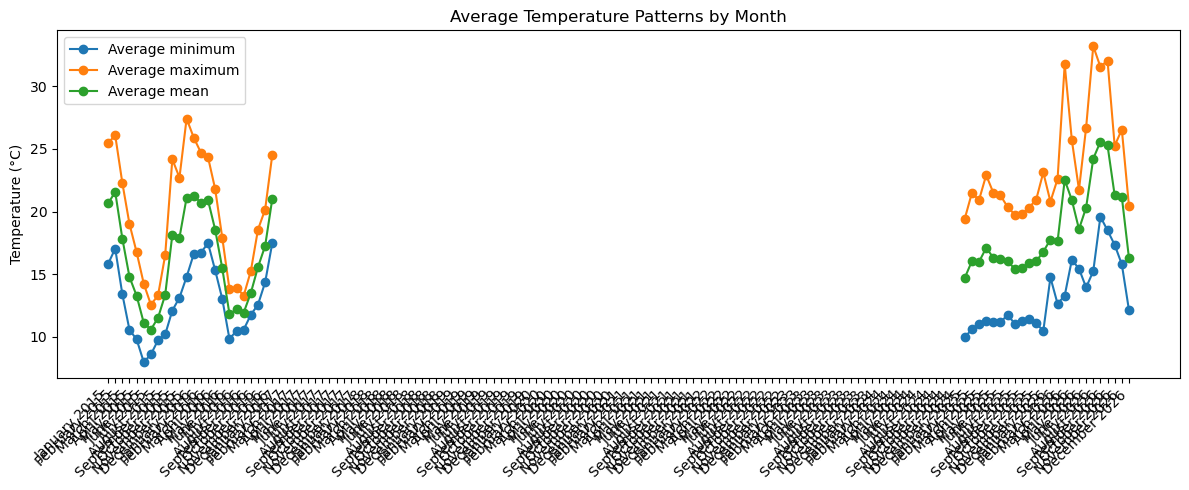

In [8]:

monthly_temperature = (
    weather_all.groupby(["year", "month_num", "month"], as_index=False)
    .agg(
        avg_min_temp_c=("min_temp_c", "mean"),
        avg_max_temp_c=("max_temp_c", "mean"),
        avg_mean_temp_c=("mean_temp_c", "mean")
    )
    .sort_values(["year", "month_num"])
)

display(monthly_temperature.round(2))

x_labels = monthly_temperature["month"] + " " + monthly_temperature["year"].astype(str)

plt.figure(figsize=(12, 5))
plt.plot(x_labels, monthly_temperature["avg_min_temp_c"], marker="o", label="Average minimum")
plt.plot(x_labels, monthly_temperature["avg_max_temp_c"], marker="o", label="Average maximum")
plt.plot(x_labels, monthly_temperature["avg_mean_temp_c"], marker="o", label="Average mean")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Temperature (°C)")
plt.title("Average Temperature Patterns by Month")
plt.legend()
plt.tight_layout()
plt.show()


## Rainfall totals and rainy-day frequency by month

,year,month_num,month,total_rainfall_mm,rainy_days,total_days,rainy_day_frequency_percent
0,2015,1,January,84.8,10,31,32.26
1,2015,2,February,66.8,10,28,35.71
2,2015,3,March,21.6,8,31,25.81
3,2015,4,April,45.8,14,30,46.67
4,2015,5,May,51.0,15,31,48.39
5,2015,6,June,100.0,12,30,40.00
6,2015,7,July,67.6,13,31,41.94
7,2015,8,August,52.4,10,31,32.26
8,2015,9,September,15.4,5,30,16.67
9,2015,10,October,19.6,10,31,32.26


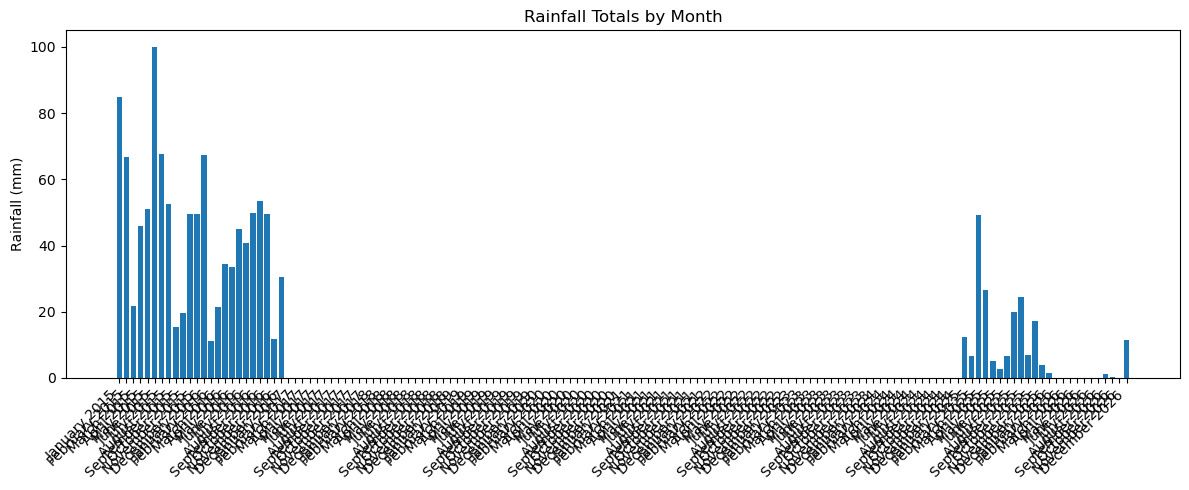

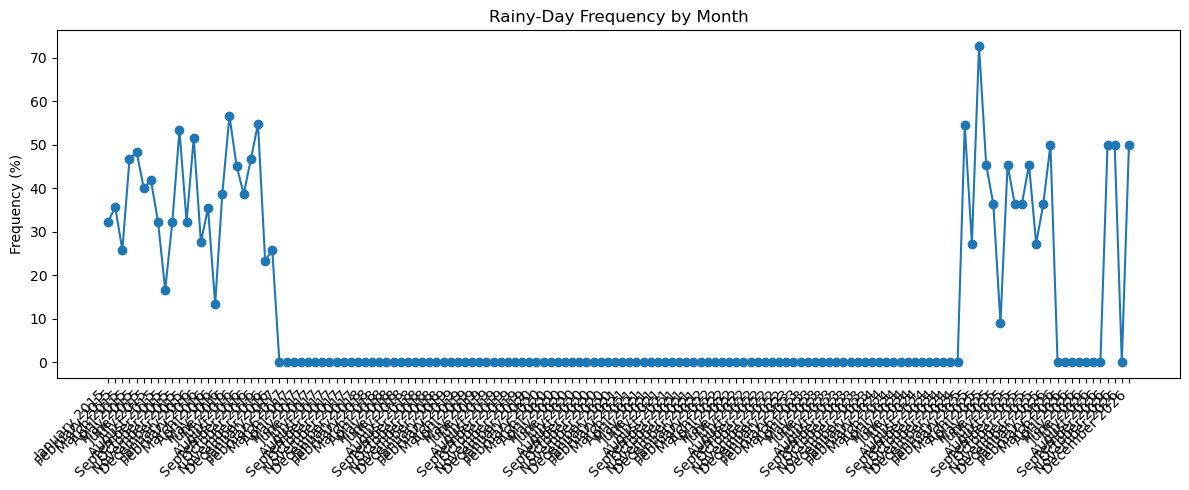

In [9]:

monthly_rainfall = (
    weather_all.groupby(["year", "month_num", "month"], as_index=False)
    .agg(
        total_rainfall_mm=("rainfall_mm", "sum"),
        rainy_days=("rainy_day", "sum"),
        total_days=("date", "count")
    )
    .sort_values(["year", "month_num"])
)

monthly_rainfall["rainy_day_frequency_percent"] = (
    monthly_rainfall["rainy_days"] / monthly_rainfall["total_days"] * 100
).round(2)

display(monthly_rainfall.round(2))

x_labels = monthly_rainfall["month"] + " " + monthly_rainfall["year"].astype(str)

plt.figure(figsize=(12, 5))
plt.bar(x_labels, monthly_rainfall["total_rainfall_mm"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Rainfall (mm)")
plt.title("Rainfall Totals by Month")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(x_labels, monthly_rainfall["rainy_day_frequency_percent"], marker="o")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Frequency (%)")
plt.title("Rainy-Day Frequency by Month")
plt.tight_layout()
plt.show()


## Weather profile by weekday

,weekday,avg_min_temp_c,avg_max_temp_c,avg_rainfall_mm,rainy_days,avg_max_gust_speed_kmh
1,Monday,12.05,19.99,0.99,50,22.70
5,Tuesday,12.69,20.15,1.73,52,22.96
6,Wednesday,12.94,20.56,1.25,45,23.76
4,Thursday,13.12,20.13,1.80,50,22.95
0,Friday,12.59,19.66,1.54,51,21.16
2,Saturday,12.79,20.17,1.19,38,21.62
3,Sunday,12.60,20.30,1.55,43,22.56


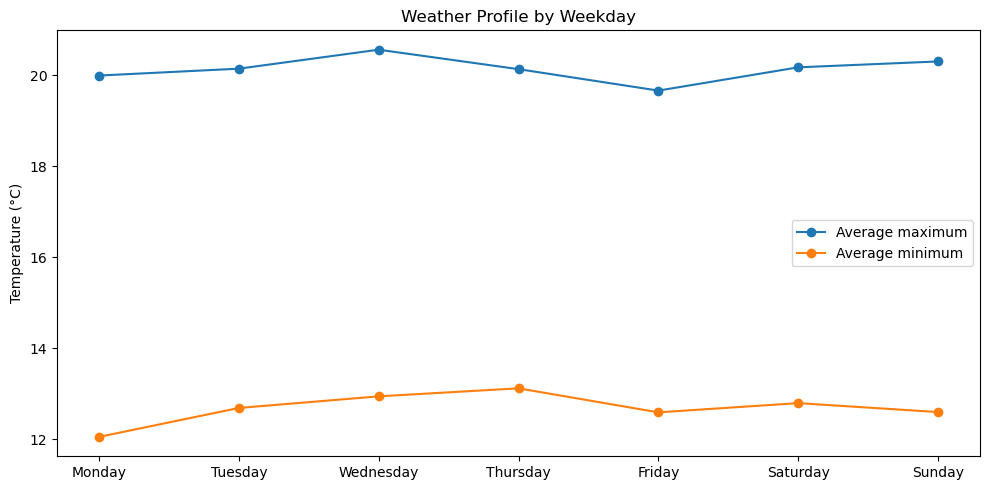

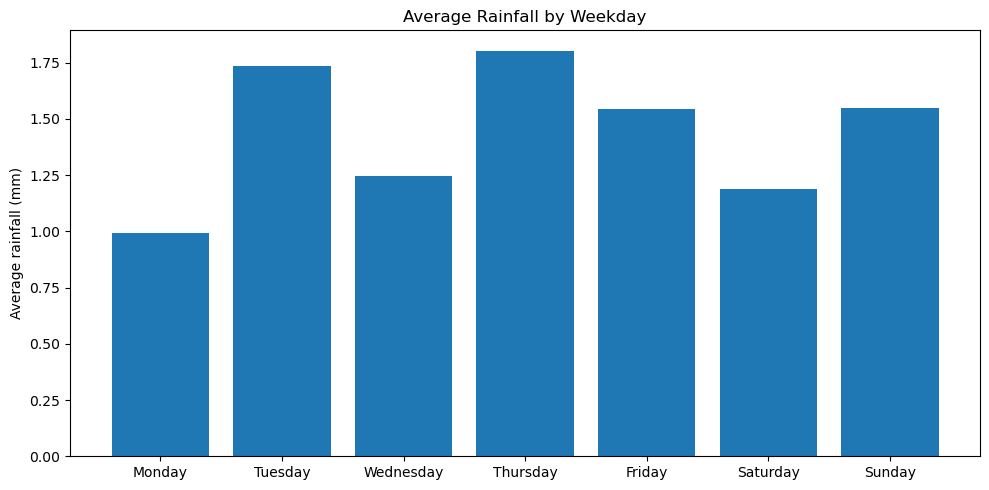

In [10]:

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekday_profile = (
    weather_all.groupby("weekday", as_index=False)
    .agg(
        avg_min_temp_c=("min_temp_c", "mean"),
        avg_max_temp_c=("max_temp_c", "mean"),
        avg_rainfall_mm=("rainfall_mm", "mean"),
        rainy_days=("rainy_day", "sum"),
        avg_max_gust_speed_kmh=("max_gust_speed_kmh", "mean")
    )
)

weekday_profile["weekday"] = pd.Categorical(weekday_profile["weekday"], categories=weekday_order, ordered=True)
weekday_profile = weekday_profile.sort_values("weekday")

display(weekday_profile.round(2))

plt.figure(figsize=(10, 5))
plt.plot(weekday_profile["weekday"], weekday_profile["avg_max_temp_c"], marker="o", label="Average maximum")
plt.plot(weekday_profile["weekday"], weekday_profile["avg_min_temp_c"], marker="o", label="Average minimum")
plt.ylabel("Temperature (°C)")
plt.title("Weather Profile by Weekday")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(weekday_profile["weekday"], weekday_profile["avg_rainfall_mm"])
plt.ylabel("Average rainfall (mm)")
plt.title("Average Rainfall by Weekday")
plt.tight_layout()
plt.show()


## Identify the most extreme weather days

In [11]:

hottest_days = weather_all.nlargest(10, "max_temp_c")[["date", "min_temp_c", "max_temp_c", "rainfall_mm", "max_gust_speed_kmh"]]
coldest_nights = weather_all.nsmallest(10, "min_temp_c")[["date", "min_temp_c", "max_temp_c", "rainfall_mm", "max_gust_speed_kmh"]]
wettest_days = weather_all.nlargest(10, "rainfall_mm")[["date", "rainfall_mm", "min_temp_c", "max_temp_c", "max_gust_speed_kmh"]]
windiest_days = weather_all.nlargest(10, "max_gust_speed_kmh")[["date", "max_gust_speed_kmh", "min_temp_c", "max_temp_c", "rainfall_mm"]]

print("Top 10 hottest days")
display(hottest_days.reset_index(drop=True))

print("Top 10 coldest nights")
display(coldest_nights.reset_index(drop=True))

print("Top 10 wettest days")
display(wettest_days.reset_index(drop=True))

print("Top 10 windiest days")
display(windiest_days.reset_index(drop=True))


Top 10 hottest days


,date,min_temp_c,max_temp_c,rainfall_mm,max_gust_speed_kmh
0,2026-09-01,18.4,42.9,0.0,67.0
1,2016-01-13,17.0,41.7,0.2,32.0
2,2026-07-01,17.6,41.1,0.0,46.0
3,2015-12-19,19.3,40.9,0.0,35.0
4,2015-12-31,21.9,39.3,0.0,24.0
5,2025-02-02,17.8,39.3,0.0,44.0
6,2016-02-23,23.1,39.1,0.0,28.0
7,2016-03-08,20.0,38.6,0.6,20.0
8,2015-01-02,15.5,38.2,0.0,22.0
9,2016-12-28,28.8,37.8,0.0,39.0


Top 10 coldest nights


,date,min_temp_c,max_temp_c,rainfall_mm,max_gust_speed_kmh
0,2015-06-21,2.3,12.6,0.0,20.0
1,2025-01-08,3.2,13.2,0.0,20.0
2,2025-03-08,3.3,19.8,0.2,15.0
3,2015-07-18,3.4,10.7,0.0,11.0
4,2015-07-19,3.4,11.6,0.0,2.0
5,2025-06-09,3.7,22.1,0.0,43.0
6,2015-06-20,4.1,11.5,0.0,13.0
7,2025-05-09,4.2,15.4,1.2,26.0
8,2025-04-07,4.3,16.1,0.2,33.0
9,2015-06-04,4.5,10.9,4.2,32.0


Top 10 wettest days


,date,rainfall_mm,min_temp_c,max_temp_c,max_gust_speed_kmh
0,2015-06-16,68.0,11.5,16.0,13.0
1,2015-12-26,30.6,12.7,29.1,24.0
2,2015-07-12,27.4,9.5,12.3,24.0
3,2016-07-05,22.6,10.2,12.3,15.0
4,2025-04-11,22.4,10.1,17.3,41.0
5,2016-04-21,21.2,15.7,19.6,11.0
6,2016-12-29,20.4,21.0,26.7,15.0
7,2015-02-14,19.6,19.0,24.8,0.0
8,2015-01-08,19.4,21.2,27.8,11.0
9,2015-01-07,19.0,19.1,37.3,39.0


Top 10 windiest days


,date,max_gust_speed_kmh,min_temp_c,max_temp_c,rainfall_mm
0,2025-12-10,76.0,10.2,20.1,2.0
1,2025-08-07,70.0,7.0,15.3,0.0
2,2026-09-01,67.0,18.4,42.9,0.0
3,2025-07-09,61.0,9.7,20.8,0.0
4,2025-01-10,59.0,10.5,18.3,1.2
5,2026-01-02,57.0,15.3,21.4,1.4
6,2025-09-10,56.0,12.5,21.2,0.0
7,2025-10-10,56.0,13.7,21.9,0.0
8,2016-10-09,54.0,17.1,21.7,0.8
9,2025-06-06,54.0,7.2,14.8,0.0


## Finished

In [12]:
output_path = BASE_DIR / "cleaned_weather_2015_2026_analysis.csv"
weather_all.to_csv(output_path, index=False)

print("Exported cleaned dataset to:", output_path.resolve())
print("Analysis finished.")

Exported cleaned dataset to: /mnt/data/cleaned_weather_2015_2026_analysis.csv
Analysis finished.
